In [ ]:
import marimo as mo

# Most Visited Floor

Using the entries table, get the total_visit for person and the most_visited_floor by that person also get all the resources_used by that person in a single field.

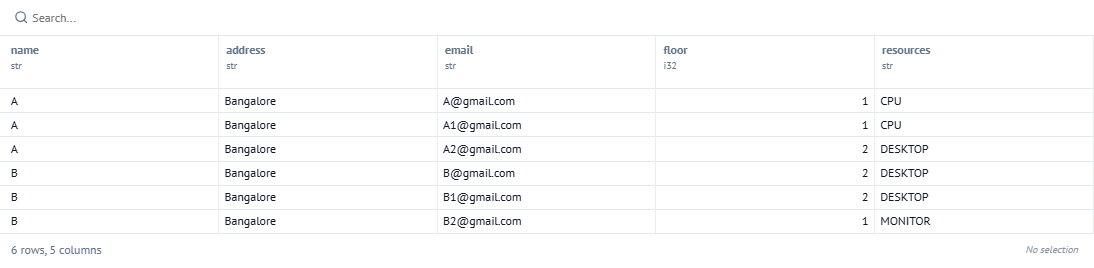

In [ ]:
_df = mo.sql(
    f"""
    DROP TABLE IF EXISTS entries;

    CREATE TABLE entries (
    	name VARCHAR(20),
    	address VARCHAR(20),
    	email VARCHAR(20),
    	floor INT,
    	resources VARCHAR(10)
    );

    INSERT INTO
    	entries
    VALUES
    	('A', 'Bangalore', 'A@gmail.com', 1, 'CPU'),
    	('A', 'Bangalore', 'A1@gmail.com', 1, 'CPU'),
    	('A', 'Bangalore', 'A2@gmail.com', 2, 'DESKTOP'),
    	('B', 'Bangalore', 'B@gmail.com', 2, 'DESKTOP'),
    	('B', 'Bangalore', 'B1@gmail.com', 2, 'DESKTOP'),
    	('B', 'Bangalore', 'B2@gmail.com', 1, 'MONITOR');

    SELECT * FROM entries;
    """
)

# Solution

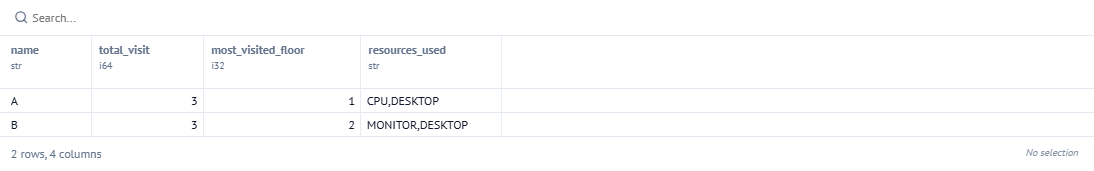

In [ ]:
_df = mo.sql(
    f"""
    WITH
    	total_visits AS (
    		SELECT
    			name,
    			COUNT(*) AS total_visit,
    			STRING_AGG(DISTINCT resources, ',') AS resources_used
    		FROM
    			entries
    		GROUP BY
    			name
    	),
    	floor_visits AS (
    		SELECT
    			name,
    			floor,
    			COUNT(*) AS no_of_floor_visit,
    			DENSE_RANK() OVER (
    				PARTITION BY
    					name
    				ORDER BY
    					COUNT(*) DESC
    			) AS visit_rank
    		FROM
    			entries
    		GROUP BY
    			name,
    			floor
    	)
    SELECT
    	name,
    	total_visit,
    	floor AS most_visited_floor,
    	resources_used
    FROM
    	floor_visits
    	INNER JOIN total_visits USING (name)
    WHERE
    	visit_rank = 1;
    """
)